# Modelo de Machine Learning - Predição Semanal de Demanda

Este notebook treina um classificador para prever a probabilidade da demanda SEMANAL ser Baixa, Média ou Alta, com seleção automática de alvo e detecção robusta de feriados.

In [21]:
# Instalação de biblioteca de feriados (se necessário)
try:
    import holidays
except ImportError:
    !pip install holidays
    import holidays

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. CARGA E SELEÇÃO AUTOMÁTICA
df = pd.read_csv('data/database_final.csv', low_memory=False)
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

# Seleciona automaticamente o par Categoria/Filial com maior volume
top_alvo = df.groupby(['CATEGORIA', 'FILIAL']).size().reset_index(name='CONTAGEM')
top_alvo = top_alvo.sort_values(by='CONTAGEM', ascending=False).iloc[0]

cat_alvo = top_alvo['CATEGORIA']
filial_alvo = top_alvo['FILIAL']

print(f"Treinando para: {cat_alvo} na {filial_alvo}")

df_filtrado = df[(df['CATEGORIA'] == cat_alvo) & (df['FILIAL'] == filial_alvo)].copy()
df_semanal = df_filtrado.set_index('DATA_ATEND').resample('W')['FATUR_VENDA'].sum().reset_index()
df_semanal.columns = ['DATA_INICIO_SEMANA', 'DEMANDA']

Treinando para: Temperos & Condimentos na SHOPPING


## 2. Rotulação e Engenharia de Atributos Robustas

In [22]:
# Limites Semanais (Quantis)
q33 = df_semanal['DEMANDA'].quantile(0.33)
q66 = df_semanal['DEMANDA'].quantile(0.66)

def rotular_demanda(valor):
    if valor <= q33: return 'Baixa'
    if valor <= q66: return 'Média'
    return 'Alta'

df_semanal['CLASSE'] = df_semanal['DEMANDA'].apply(rotular_demanda)

# Detecção Dinâmica de Feriados
br_holidays = holidays.Brazil()

def tem_feriado_robusto(row):
    data_fim = row['DATA_INICIO_SEMANA']
    periodo = pd.date_range(start=data_fim - pd.Timedelta(days=6), end=data_fim)
    for data in periodo:
        if data in br_holidays: return 1
    return 0

df_semanal['MES'] = df_semanal['DATA_INICIO_SEMANA'].dt.month
df_semanal['TEM_FERIADO'] = df_semanal.apply(tem_feriado_robusto, axis=1)

X = df_semanal[['MES', 'TEM_FERIADO']]
y = df_semanal['CLASSE']

## 3. Validação Cruzada Customizada (K-Fold)

Para garantir uma avaliação robusta seguindo a regra de negócio:
1. **Preservação de Padrões Únicos:** Combinações de `MES` e `TEM_FERIADO` que ocorrem apenas uma vez no dataset são forçadas para o conjunto de treinamento em todos os folds.
2. **Cálculo de Métricas:** Comparamos a classe predita (faixa de demanda com maior probabilidade) com a classe real. Como as classes são definidas pelos quantis da demanda, acertar a classe significa que o valor real de faturamento caiu dentro da faixa predita.
3. **Métricas Detalhadas:** Calculamos Acurácia, Precisão, Revocação e F1-Score para cada iteração.

--- RESULTADOS DETALHADOS DA VALIDAÇÃO ---
      Data Faturamento Real Classe Real Predição Probabilidade
2024-01-07      R$ 7,047.87       Baixa    Baixa        83.00%
2024-01-14      R$ 8,431.63       Baixa    Baixa        94.27%
2024-01-21      R$ 8,233.01       Baixa    Baixa        95.65%
2024-01-28      R$ 7,691.11       Baixa    Baixa        95.69%
2024-02-04      R$ 9,739.67       Média    Baixa        67.16%
2024-02-11      R$ 9,572.17       Média    Baixa        66.73%
2024-02-18      R$ 7,628.17       Baixa    Média        65.64%
2024-02-25      R$ 8,734.63       Baixa    Média        62.29%
2024-03-03      R$ 9,756.45       Média    Média        51.12%
2024-03-10     R$ 10,204.38        Alta    Média        56.46%
2024-03-17     R$ 10,054.42       Média     Alta        35.42%
2024-03-24      R$ 7,850.93       Baixa    Média        51.12%
2024-04-07     R$ 10,785.02        Alta    Baixa        53.10%
2024-04-14     R$ 10,536.91        Alta    Baixa        49.29%
2024-04-28  

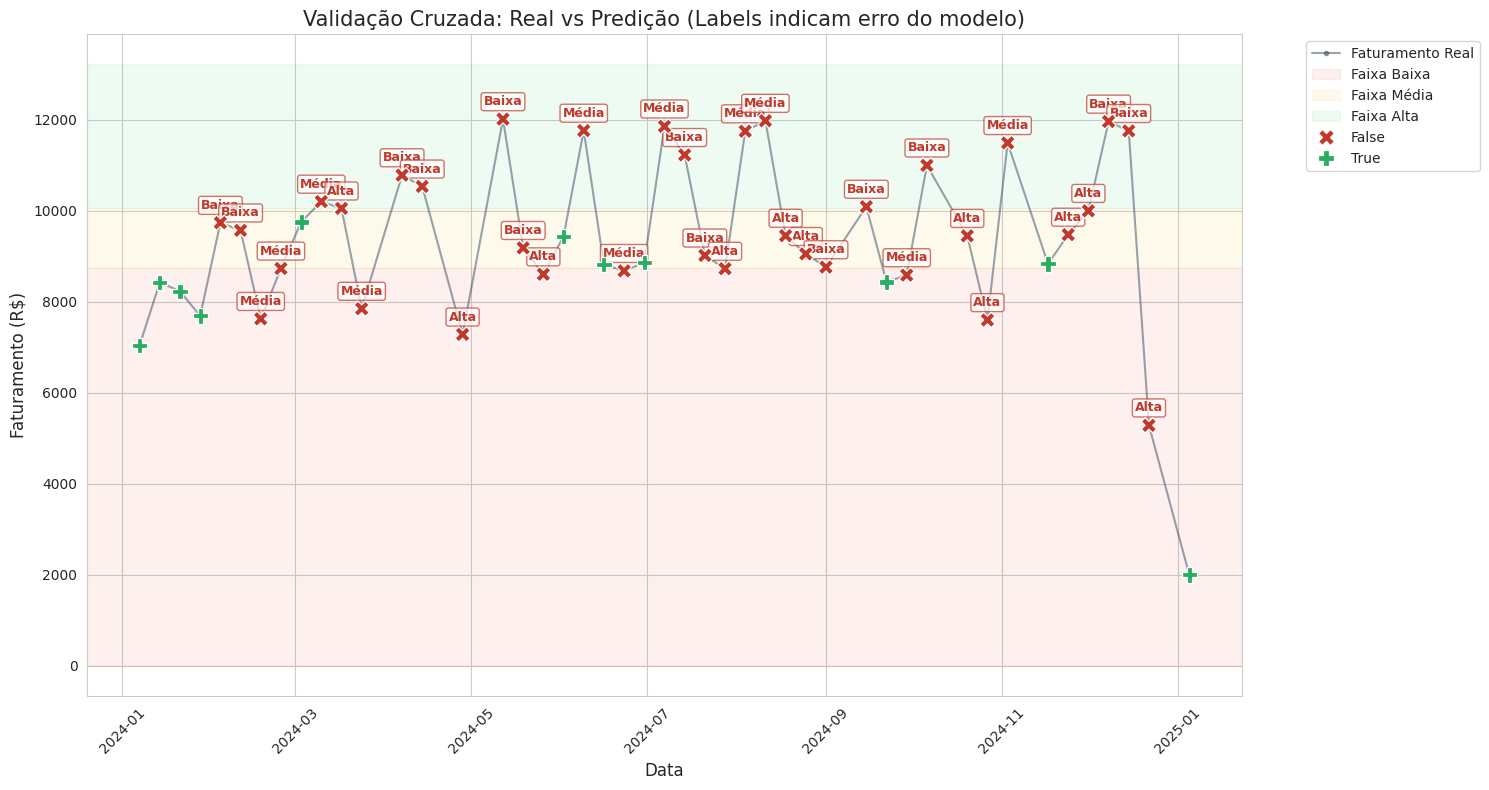

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração da Validação Cruzada
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Identificar amostras com combinações únicas de (MES, TEM_FERIADO)
contagem = df_semanal.groupby(['MES', 'TEM_FERIADO']).size().reset_index(name='n')
combos_unicos = contagem[contagem['n'] == 1][['MES', 'TEM_FERIADO']]

df_semanal['ES_UNICO'] = df_semanal.set_index(['MES', 'TEM_FERIADO']).index.isin(
    combos_unicos.set_index(['MES', 'TEM_FERIADO']).index
)

idx_unicos = df_semanal[df_semanal['ES_UNICO']].index
idx_split = df_semanal[~df_semanal['ES_UNICO']].index

X_split = X.loc[idx_split]
y_split = y.loc[idx_split]

historico_metrics = []
resultados_validacao = []

for fold, (train_sub_idx, val_sub_idx) in enumerate(skf.split(X_split, y_split), 1):
    train_idx = list(idx_split[train_sub_idx]) + list(idx_unicos)
    val_idx = list(idx_split[val_sub_idx])
    
    X_train_fold, X_val_fold = X.loc[train_idx], X.loc[val_idx]
    y_train_fold, y_val_fold = y.loc[train_idx], y.loc[val_idx]
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_train_fold, y_train_fold)
    
    y_pred = clf.predict(X_val_fold)
    y_prob = clf.predict_proba(X_val_fold)
    
    for i, idx in enumerate(val_idx):
        max_prob = max(y_prob[i])
        resultados_validacao.append({
            'Data': df_semanal.loc[idx, 'DATA_INICIO_SEMANA'],
            'Faturamento Real': df_semanal.loc[idx, 'DEMANDA'],
            'Classe Real': y_val_fold.iloc[i],
            'Predição': y_pred[i],
            'Probabilidade': max_prob
        })
    
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val_fold, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val_fold, y_pred, average='weighted', zero_division=0)
    
    historico_metrics.append([fold, acc, prec, rec, f1])

df_res_val = pd.DataFrame(resultados_validacao).sort_values('Data')
print("--- RESULTADOS DETALHADOS DA VALIDAÇÃO ---")
print(df_res_val.to_string(index=False, formatters={'Probabilidade': '{:,.2%}'.format, 'Faturamento Real': 'R$ {:,.2f}'.format}))

df_results = pd.DataFrame(historico_metrics, columns=['Fold', 'Acurácia', 'Precisão', 'Revocação', 'F1-Score'])
print("\n--- MÉDIA DOS FOLDS ---")
print(df_results.drop(columns='Fold').mean())

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

plt.plot(df_res_val['Data'], df_res_val['Faturamento Real'], color='#34495e', linewidth=1.5, label='Faturamento Real', alpha=0.5, marker='o', markersize=3)

plt.axhspan(0, q33, color='#e74c3c', alpha=0.08, label='Faixa Baixa')
plt.axhspan(q33, q66, color='#f1c40f', alpha=0.08, label='Faixa Média')
plt.axhspan(q66, df_res_val['Faturamento Real'].max()*1.1, color='#2ecc71', alpha=0.08, label='Faixa Alta')

df_res_val['Acerto'] = df_res_val['Classe Real'] == df_res_val['Predição']
sns.scatterplot(data=df_res_val, x='Data', y='Faturamento Real', hue='Acerto', 
                palette={True: '#27ae60', False: '#c0392b'}, s=120, zorder=5, 
                style='Acerto', markers={True: 'P', False: 'X'})

# Adicionar anotações para os erros
for i, row in df_res_val.iterrows():
    if not row['Acerto']:
        plt.annotate(f"{row['Predição']}", 
                     (row['Data'], row['Faturamento Real']), 
                     textcoords="offset points", xytext=(0,10), ha='center', 
                     fontsize=9, color='#c0392b', fontweight='bold', 
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='#c0392b'))

plt.title('Validação Cruzada: Real vs Predição (Labels indicam erro do modelo)', fontsize=15)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Modelo Final e Interface de Predição

Para a aplicação em produção, treinamos o modelo com a base completa (X, y) para extrair o máximo de conhecimento.

In [24]:
# Treino Final
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X, y)

def prever_probabilidades_robusto(ano, mes, dia):
    data_alvo = pd.to_datetime(f"{ano}-{mes:02d}-{dia:02d}")
    periodo = pd.date_range(start=data_alvo - pd.Timedelta(days=3), end=data_alvo + pd.Timedelta(days=3))
    
    feriado_flag = 0
    for d in periodo:
        if d in br_holidays: 
            feriado_flag = 1
            break
    
    input_data = pd.DataFrame({'MES': [mes], 'TEM_FERIADO': [feriado_flag]})
    probs = model.predict_proba(input_data)[0]
    
    # Busca faturamento histórico de 2024
    try:
        data_ref_2024 = pd.to_datetime(f"2024-{mes:02d}-{dia:02d}")
        mask = df_semanal['DATA_INICIO_SEMANA'] >= data_ref_2024
        fatur_2024 = df_semanal[mask].iloc[0]['DEMANDA']
        msg_fatur = f"R$ {fatur_2024:,.2f}"
    except:
        msg_fatur = "Não encontrado na base"

    print(f"\nPredição Semanal para data em {data_alvo.date()}:")
    print(f"- Feriado Detectado na Semana: {'Sim' if feriado_flag else 'Não'}")
    print(f"- Faturamento na mesma semana de 2024: {msg_fatur}")
    
    # Definição das faixas para exibição
    faixas = {
        'Baixa': f"(< R$ {q33:,.2f})",
        'Média': f"(R$ {q33:,.2f} a R$ {q66:,.2f})",
        'Alta': f"(> R$ {q66:,.2f})"
    }
    
    print("\nProbabilidades por Faixa de Demanda:")
    for i, classe in enumerate(model.classes_):
        desc_faixa = faixas.get(classe, "")
        print(f"  * {classe} {desc_faixa}: {probs[i]*100:.2f}%")
    
    return dict(zip(model.classes_, probs))

# Exemplo: Semana do 7 de Setembro de 2025
prever_probabilidades_robusto(2025, 9, 7)


Predição Semanal para data em 2025-09-07:
- Feriado Detectado na Semana: Sim
- Faturamento na mesma semana de 2024: R$ 14,078.33

Probabilidades por Faixa de Demanda:
  * Alta (> R$ 10,066.61): 93.95%
  * Baixa (< R$ 8,739.35): 0.00%
  * Média (R$ 8,739.35 a R$ 10,066.61): 6.05%


{'Alta': np.float64(0.9394602944225586),
 'Baixa': np.float64(0.0),
 'Média': np.float64(0.06053970557744143)}